# Experimental setup

Set up for the experiment. This will load in the required packages, load in the data set, and load in the model. Then the experiment is run on the data set, saving the model weights and the results so they can be reloaded later. Below are the returned metrics.

## Metrics

- Overall performance in learned tasks: Usually average accuracy and average incremental accuracy, and confusion matrix
- Memory stability of old classes: uses forgetting measure (average forgetting of old tasks) and backward transfer (average influence of learning the k-th task on all old tasks)
- Learning plasticity of new classes: intransience measure (inability to learn a new task) and forward transfer (average influence of all old tasks on the current task)
- Resource (storage) and computational overheads (big O complexity), RAM usage.
- Discrepancy of task distribution

In [21]:
#TODO:
# Alter to use separate training functions for each training group and separate test functions out from the training function

## Imports

In [22]:
# Load packages
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import transforms


import numpy as np
import matplotlib.pyplot as plt

import os
import time

from collections import defaultdict

print(torch.__version__)
print(torch.cuda.is_available())
torch.set_default_device('cuda')

2.10.0+cu128
True


In [23]:
# Parameters

LOAD_FROM_FILE = False
FILE_LOAD_PATH = os.path.join(os.getcwd(), 'models', 'model_weights.pth')

TEST_INTERVAL = 'class' # Can be 'class', 'batch', or None. 
TEST_EVERY_N = 100 # Number of batches between tests, only used if TEST_INTERVAL='batch'


In [ ]:
# Check for necessary output folders

folder_path = os.path.join(os.getcwd(), 'datasets')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'results')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Load dataset and model
dataset_path = os.path.join(os.getcwd(), 'datasets')

download = not (os.path.exists(dataset_path))

print('Downloading dataset:',download)

print('Dataset path:', dataset_path)

# Define the desired size for the input tensors
desired_size = (224, 224)

# Create a transformation to resize the input tensors
resize_transform = transforms.Compose([
    transforms.Resize(desired_size),
    transforms.ToTensor()
])

dataset_train = torchvision.datasets.Imagenette(root = dataset_path, 
                                          split = 'train', 
                                          download = download, transform = resize_transform
                                          )

dataset_test = torchvision.datasets.Imagenette(root = dataset_path, 
                                          split = 'val', 
                                          download = download, transform = resize_transform
                                          )

def group_indices_by_class(dataset):
    class_to_indices = defaultdict(list)
    for idx in range(len(dataset)):
        _, y = dataset[idx]
        class_to_indices[int(y)].append(idx)
    return class_to_indices

class ContinualClassStream(torch.utils.data.IterableDataset):
    def __init__(self, dataset, class_order, class_to_indices):
        self.dataset = dataset
        self.class_order = class_order
        self.class_to_indices = class_to_indices

    def __iter__(self):
        for cls in self.class_order:
            for idx in self.class_to_indices[cls]:
                yield self.dataset[idx]

class_to_indices_train = group_indices_by_class(dataset_train)
class_order_train = sorted(class_to_indices_train.keys())  # or any order you want

train_stream = ContinualClassStream(dataset_train, class_order_train, class_to_indices_train)

train_dataloader = DataLoader(
    train_stream,
    batch_size=1,
    num_workers=0  # IMPORTANT for online streams
)

class_to_indices_test = group_indices_by_class(dataset_test)
class_order_test = sorted(class_to_indices_test.keys())  # or any order you want

test_stream = ContinualClassStream(dataset_test, class_order_test, class_to_indices_test)
test_dataloader = DataLoader(
    test_stream,
    batch_size=1,
    num_workers=0  # IMPORTANT for online streams
)

model = torchvision.models.convnext_tiny()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using {device} device")
print(model)


Dataset path: c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\datasets
Using cuda device
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()

In [ ]:
# Create training metaparameters

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

epochs = 1

In [26]:
# Training fcns

def train(dataloader, model, loss_fn, optimizer, test_dataloader=None, test_fn=None, 
          test_interval='class', test_every_n=100, class_order=None):
    """
    Train on continual learning stream with per-class tracking and optional intermediate testing.
    
    Args:
        dataloader: DataLoader with ContinualClassStream
        model: Model to train
        loss_fn: Loss function
        optimizer: Optimizer
        test_dataloader: Optional DataLoader for testing between training phases
        test_fn: Test function to call (should be the test function)
        test_interval: 'class' (test after each class), 'batch' (test every N batches), or None (no intermediate testing)
        test_every_n: Number of batches between tests (only used if test_interval='batch')
        class_order: List of class labels in order (for per-class metrics)
    
    Returns:
        Dictionary with training metrics per class and test metrics history
    """
    model.train()
    batch_count = 0
    current_class = None
    class_batch_counts = defaultdict(int)
    class_losses = defaultdict(float)
    training_metrics = {}
    test_history = []  # Track test metrics over time
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_class = int(y[0].item())  # Get class label from batch
        
        # Track when we transition to a new class
        if current_class != y_class:
            if current_class is not None:
                avg_loss = class_losses[current_class] / class_batch_counts[current_class]
                training_metrics[current_class] = {
                    'samples': class_batch_counts[current_class],
                    'avg_loss': avg_loss
                }
                print(f"  Class {current_class} - Processed {class_batch_counts[current_class]} samples, Avg loss: {avg_loss:>7f}")
                
                # Test after each class if requested
                if test_interval == 'class' and test_dataloader is not None and test_fn is not None:
                    print(f"  Testing after Class {current_class}:")
                    test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
                    test_result['step'] = current_class  # Track which class we just trained
                    test_result['step_type'] = 'class'
                    test_history.append(test_result)
                    model.train()  # Return to training mode
            
            current_class = y_class
            print(f"Starting training on Class {current_class}")

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        class_batch_counts[current_class] += 1
        class_losses[current_class] += loss.item()
        batch_count += 1

        if batch % 100 == 0 and batch > 0:
            print(f"  Batch {batch}: loss: {loss.item():>7f}")
            
            # Test every N batches if requested
            if test_interval == 'batch' and batch % test_every_n == 0 and test_dataloader is not None and test_fn is not None:
                print(f"  Testing at Batch {batch}:")
                test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
                test_result['step'] = batch  # Track which batch we're at
                test_result['step_type'] = 'batch'
                test_history.append(test_result)
                model.train()  # Return to training mode
    
    # Print final class stats
    if current_class is not None:
        avg_loss = class_losses[current_class] / class_batch_counts[current_class]
        training_metrics[current_class] = {
            'samples': class_batch_counts[current_class],
            'avg_loss': avg_loss
        }
        print(f"  Class {current_class} - Processed {class_batch_counts[current_class]} samples, Avg loss: {avg_loss:>7f}")
        
        # Final test after last class if requested
        if test_interval == 'class' and test_dataloader is not None and test_fn is not None:
            print(f"  Testing after Class {current_class}:")
            test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
            test_result['step'] = current_class
            test_result['step_type'] = 'class'
            test_history.append(test_result)
            model.train()  # Return to training mode
    
    print(f"Training complete. Total batches: {batch_count}\n")
    return training_metrics, test_history


def test(dataloader, model, loss_fn, class_order=None):
    """
    Test on continual learning stream with comprehensive continual learning metrics.
    
    Metrics computed (based on continual learning survey):
    - Per-class accuracy: Accuracy on each class
    - Overall accuracy: Average accuracy across all classes
    - Backward Transfer (BWT): Average change in previous task accuracy after learning new tasks
    - Forward Transfer (FWT): Average improvement on new tasks from learning previous tasks
    - Average Forgetting (AF): Average decrease in accuracy on old tasks
    
    Args:
        dataloader: DataLoader with ContinualClassStream
        model: Model to evaluate
        loss_fn: Loss function
        class_order: List of class labels in order (for per-class metrics)
    
    Returns:
        Dictionary with test metrics including per-class metrics, overall metrics, and continual learning metrics
    """
    model.eval()
    
    test_loss = 0.0
    correct = 0
    total = 0
    
    current_class = None
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    class_losses = defaultdict(float)
    class_batch_counts = defaultdict(int)
    confusion_matrix = {}  # Track predictions per class
    test_metrics = {}
    
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            y_class = int(y[0].item())  # Get class label from batch
            
            # Track when we transition to a new class
            if current_class != y_class:
                if current_class is not None:
                    class_acc = (100 * class_correct[current_class] / class_total[current_class])
                    class_avg_loss = class_losses[current_class] / class_batch_counts[current_class]
                    test_metrics[current_class] = {
                        'accuracy': class_acc,
                        'avg_loss': class_avg_loss,
                        'total_samples': class_total[current_class]
                    }
                    print(f"  Class {current_class} - Accuracy: {class_acc:>0.1f}%, Avg loss: {class_avg_loss:>8f}")
                current_class = y_class
                print(f"Testing on Class {current_class}")
            
            pred = model(X)
            loss = loss_fn(pred, y)
            
            test_loss += loss.item()
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
            # Per-class tracking
            y_class_label = int(y[0].item())
            pred_class_label = int(pred.argmax(1)[0].item())
            class_total[y_class_label] += 1
            class_losses[y_class_label] += loss.item()
            class_batch_counts[y_class_label] += 1
            class_correct[y_class_label] += (pred.argmax(1) == y).type(torch.float).sum().item()
            
            # Build confusion matrix
            if y_class_label not in confusion_matrix:
                confusion_matrix[y_class_label] = defaultdict(int)
            confusion_matrix[y_class_label][pred_class_label] += 1
    
    # Print final class stats and compute per-class accuracies
    per_class_accuracies = {}
    if current_class is not None:
        class_acc = (100 * class_correct[current_class] / class_total[current_class])
        class_avg_loss = class_losses[current_class] / class_batch_counts[current_class]
        test_metrics[current_class] = {
            'accuracy': class_acc,
            'avg_loss': class_avg_loss,
            'total_samples': class_total[current_class]
        }
        print(f"  Class {current_class} - Accuracy: {class_acc:>0.1f}%, Avg loss: {class_avg_loss:>8f}")
    
    # Compile all per-class accuracies
    for cls in sorted(test_metrics.keys()):
        per_class_accuracies[cls] = test_metrics[cls]['accuracy']
    
    # Overall metrics
    avg_loss = test_loss / (batch + 1) if batch >= 0 else 0
    overall_accuracy = 100 * correct / total if total > 0 else 0
    average_task_accuracy = np.mean(list(per_class_accuracies.values())) if per_class_accuracies else 0
    
    test_metrics['overall'] = {
        'accuracy': overall_accuracy,
        'avg_loss': avg_loss,
        'total_samples': total,
        'average_task_accuracy': average_task_accuracy,
        'per_class_accuracies': per_class_accuracies,
        'confusion_matrix': dict(confusion_matrix)
    }
    
    print(f"\nTest Summary:")
    print(f"  Overall Accuracy: {overall_accuracy:>0.1f}%")
    print(f"  Average Task Accuracy: {average_task_accuracy:>0.1f}%")
    print(f"  Overall Avg Loss: {avg_loss:>8f}\n")
    
    return test_metrics


In [27]:
# Training

# Option 1: Test after each class
if TEST_INTERVAL == 'class':
    train_metrics, test_history = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='class')

# Option 2: Test every N batches

elif TEST_INTERVAL == 'batch':
    train_metrics, test_history = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='batch', test_every_n=TEST_EVERY_N)

# Option 3: No intermediate testing

else:
    test_history = []
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)
        test_result = test(test_dataloader, model, loss_fn)
        test_result['step'] = t + 1
        test_result['step_type'] = 'epoch'
        test_history.append(test_result)

##################

print("Done!")

timestr = time.strftime("%Y%m%d-%H%M%S")

# save testing metrics

torch.save(test_history, os.path.join(os.getcwd(), 'results', timestr + 'train_metrics.pth'))

# save model weights

torch.save(model.state_dict(), os.path.join(os.getcwd(), 'models', timestr + 'model_weights.pth'))
print("Saved PyTorch Model State to " + timestr + "model_weights.pth")


Starting training on Class 0
  Batch 100: loss: 0.005123
  Batch 200: loss: 0.002752
  Batch 300: loss: 0.002122
  Batch 400: loss: 0.001519
  Batch 500: loss: 0.001459
  Batch 600: loss: 0.001022
  Batch 700: loss: 0.000896
  Batch 800: loss: 0.000781
  Batch 900: loss: 0.000805
  Class 0 - Processed 963 samples, Avg loss: 0.012239
  Testing after Class 0:
Testing on Class 0
  Class 0 - Accuracy: 100.0%, Avg loss: 0.000666
Testing on Class 1
  Class 1 - Accuracy: 0.0%, Avg loss: 15.082959
Testing on Class 2
  Class 2 - Accuracy: 0.0%, Avg loss: 13.890338
Testing on Class 3
  Class 3 - Accuracy: 0.0%, Avg loss: 14.614279
Testing on Class 4
  Class 4 - Accuracy: 0.0%, Avg loss: 14.994326
Testing on Class 5
  Class 5 - Accuracy: 0.0%, Avg loss: 14.222219
Testing on Class 6
  Class 6 - Accuracy: 0.0%, Avg loss: 14.854850
Testing on Class 7
  Class 7 - Accuracy: 0.0%, Avg loss: 14.830759
Testing on Class 8
  Class 8 - Accuracy: 0.0%, Avg loss: 14.631614
Testing on Class 9
  Class 9 - Accur

RuntimeError: Parent directory c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\results does not exist.

In [28]:
torch.save(test_history, os.path.join(os.getcwd(), 'results', timestr + 'train_metrics.pth'))

# save model weights

torch.save(model.state_dict(), os.path.join(os.getcwd(), 'models', timestr + 'model_weights.pth'))
print("Saved PyTorch Model State to " + timestr + "model_weights.pth")

Saved PyTorch Model State to 20260127-153339model_weights.pth


CONTINUAL LEARNING EVALUATION METRICS

1. FINAL PERFORMANCE METRICS
--------------------------------------------------------------------------------
Overall Accuracy: 9.94%
Average Task Accuracy: 10.00%
Overall Average Loss: 11.392509

Per-Class Accuracy:
  Class 0: 0.00%
  Class 1: 0.00%
  Class 2: 0.00%
  Class 3: 0.00%
  Class 4: 0.00%
  Class 5: 0.00%
  Class 6: 0.00%
  Class 7: 0.00%
  Class 8: 0.00%
  Class 9: 100.00%

2. CONTINUAL LEARNING METRICS (from Survey)
--------------------------------------------------------------------------------
Average Forgetting (AF): 11.11%
  (measures how much old tasks were forgotten)

Task Learning Progression:
  Class 0: First evaluation: 100.00%, Final: 0.00%
  Class 1: First evaluation: 0.00%, Final: 0.00%
  Class 2: First evaluation: 0.00%, Final: 0.00%
  Class 3: First evaluation: 0.00%, Final: 0.00%
  Class 4: First evaluation: 0.00%, Final: 0.00%
  Class 5: First evaluation: 0.00%, Final: 0.00%
  Class 6: First evaluation: 0.00%, Final: 

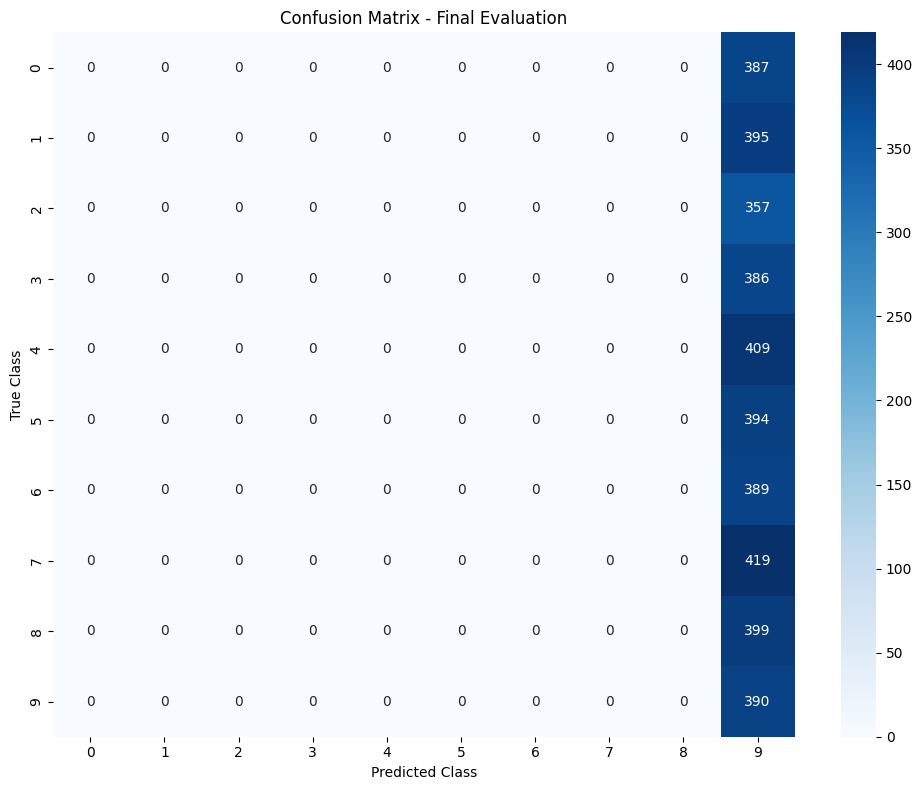


Confusion Matrix (rows: true class, columns: predicted class)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

4. METRICS OVER TIME
--------------------------------------------------------------------------------


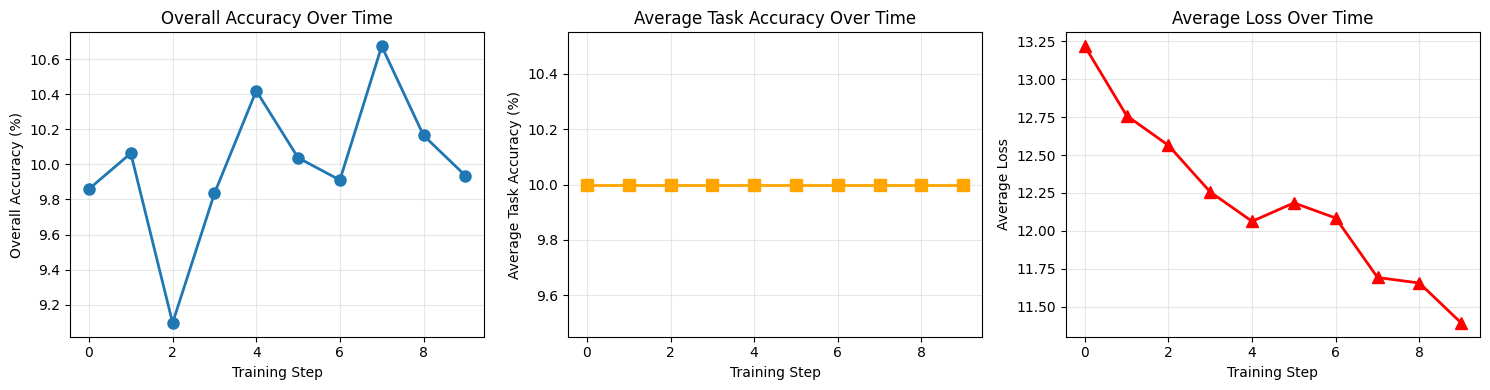

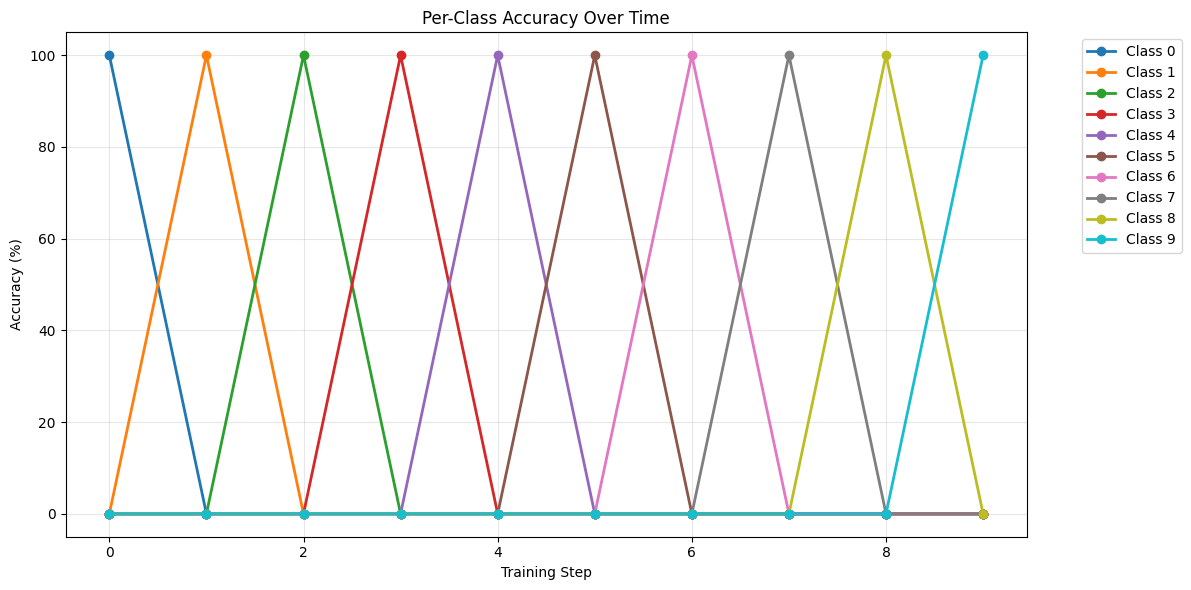

In [29]:
# Metrics and plots
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
import seaborn as sns

print("=" * 80)
print("CONTINUAL LEARNING EVALUATION METRICS")
print("=" * 80)

# Extract final test metrics
final_test_result = test_history[-1] if test_history else {}
final_overall = final_test_result.get('overall', {})
per_class_acc = final_overall.get('per_class_accuracies', {})
confusion_mat = final_overall.get('confusion_matrix', {})

print("\n1. FINAL PERFORMANCE METRICS")
print("-" * 80)
print(f"Overall Accuracy: {final_overall.get('accuracy', 0):>0.2f}%")
print(f"Average Task Accuracy: {final_overall.get('average_task_accuracy', 0):>0.2f}%")
print(f"Overall Average Loss: {final_overall.get('avg_loss', 0):>8f}")

print("\nPer-Class Accuracy:")
for cls in sorted(per_class_acc.keys()):
    print(f"  Class {cls}: {per_class_acc[cls]:>0.2f}%")

# Compute continual learning metrics
print("\n2. CONTINUAL LEARNING METRICS (from Survey)")
print("-" * 80)

if len(test_history) > 1:
    # Initialize arrays for backward and forward transfer
    backward_transfer = []
    forward_transfer = []
    forgetting = []
    
    # Get per-class accuracies from each test step
    class_accuracies_per_step = {}
    
    for step_idx, test_result in enumerate(test_history):
        overall = test_result.get('overall', {})
        per_class = overall.get('per_class_accuracies', {})
        for cls in per_class:
            if cls not in class_accuracies_per_step:
                class_accuracies_per_step[cls] = []
            class_accuracies_per_step[cls].append((step_idx, per_class[cls]))
    
    # Compute Backward Transfer: average decrease in accuracy on old tasks
    # BWT = (1/(T-1)) * sum_{i=1}^{T-1} (a_{T,i} - a_{i,i})
    # where a_{j,i} is accuracy on task i at time j
    num_tasks = len(class_accuracies_per_step)
    if num_tasks > 1:
        total_bwt = 0
        for task_id in sorted(class_accuracies_per_step.keys())[:-1]:  # All but last task
            accuracies = [acc for _, acc in sorted(class_accuracies_per_step[task_id])]
            if len(accuracies) > 1:
                initial_acc = accuracies[0]  # Accuracy right after learning the task
                final_acc = accuracies[-1]   # Accuracy at the end
                task_forgetting = initial_acc - final_acc
                total_bwt += task_forgetting
                forgetting.append(task_forgetting)
        
        if forgetting:
            avg_forgetting = np.mean(forgetting)
            print(f"Average Forgetting (AF): {avg_forgetting:>0.2f}%")
            print(f"  (measures how much old tasks were forgotten)")
    
    # Forward Transfer: not directly applicable in standard setting, show task learning curve instead
    print(f"\nTask Learning Progression:")
    for task_id in sorted(class_accuracies_per_step.keys()):
        accuracies = [acc for _, acc in sorted(class_accuracies_per_step[task_id])]
        if accuracies:
            print(f"  Class {task_id}: First evaluation: {accuracies[0]:>0.2f}%, Final: {accuracies[-1]:>0.2f}%")

# Confusion Matrix Visualization
if confusion_mat:
    print("\n3. CONFUSION MATRIX")
    print("-" * 80)
    
    # Convert confusion matrix dict to numpy array
    all_classes = sorted(set(
        list(confusion_mat.keys()) + 
        [item for subdict in confusion_mat.values() for item in subdict.keys()]
    ))
    
    cm_array = np.zeros((len(all_classes), len(all_classes)))
    for true_cls in confusion_mat:
        for pred_cls in confusion_mat[true_cls]:
            true_idx = all_classes.index(true_cls)
            pred_idx = all_classes.index(pred_cls)
            cm_array[true_idx, pred_idx] = confusion_mat[true_cls][pred_cls]
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues', 
                xticklabels=all_classes, yticklabels=all_classes)
    plt.title('Confusion Matrix - Final Evaluation')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()
    
    print("\nConfusion Matrix (rows: true class, columns: predicted class)")
    print(f"Classes: {all_classes}")

# Metrics Over Time
if len(test_history) > 1:
    print("\n4. METRICS OVER TIME")
    print("-" * 80)
    
    overall_accs = [t.get('overall', {}).get('accuracy', 0) for t in test_history]
    avg_task_accs = [t.get('overall', {}).get('average_task_accuracy', 0) for t in test_history]
    avg_losses = [t.get('overall', {}).get('avg_loss', 0) for t in test_history]
    
    steps = [t.get('step', i) for i, t in enumerate(test_history)]
    
    # Plot metrics over time
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Overall Accuracy
    axes[0].plot(steps, overall_accs, marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Overall Accuracy (%)')
    axes[0].set_title('Overall Accuracy Over Time')
    axes[0].grid(True, alpha=0.3)
    
    # Average Task Accuracy
    axes[1].plot(steps, avg_task_accs, marker='s', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Average Task Accuracy (%)')
    axes[1].set_title('Average Task Accuracy Over Time')
    axes[1].grid(True, alpha=0.3)
    
    # Average Loss
    axes[2].plot(steps, avg_losses, marker='^', linewidth=2, markersize=8, color='red')
    axes[2].set_xlabel('Training Step')
    axes[2].set_ylabel('Average Loss')
    axes[2].set_title('Average Loss Over Time')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Per-class accuracy over time
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for cls in sorted(class_accuracies_per_step.keys()):
        steps_for_class = [s for s, _ in sorted(class_accuracies_per_step[cls])]
        accs_for_class = [acc for _, acc in sorted(class_accuracies_per_step[cls])]
        ax.plot(steps_for_class, accs_for_class, marker='o', label=f'Class {cls}', linewidth=2)
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy Over Time')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
